
# Boolean Circuit 4 — transition-matrix theorem model
## Hand-coded permutation matrices, outcome composition, process-local supervision

This notebook intentionally simplifies the Transformer one step further.

The goal is not to replace the one-layer causal-Transformer experiment. The goal is to isolate a mathematical object that can support exact theorems.

For every legal reversible Boolean gate $g$, define a trainable stochastic transition matrix

$$
P_g\in\mathbb{R}^{16\times16},
\qquad
P_g[s,s'] = p_\theta(s'\mid s,g).
$$

The exact Boolean algorithm is represented by the permutation matrix

$$
P_g^\star[s,s']
=
\mathbf 1[s'=\Phi_g(s)].
$$

This gives us a direct matrix-level notion of algorithm recovery.

### Same model class for both supervision conditions

The outcome model computes

$$
p_D
=
e_{s_0}^{\top}
P_{g_1}P_{g_2}P_{g_3}P_{g_4}
$$

and receives loss only on the final state \(s_4\).

The process model uses the **same matrices** but receives local losses

$$
-\sum_{t=1}^{4}
\log P_{g_t}[s_{t-1},s_t].
$$

Therefore:

- both conditions have exactly the same trainable parameters;
- the exact hand-coded algorithm lies in the hypothesis class of both;
- outcome failure cannot be attributed to insufficient representational capacity;
- the only difference is how supervision reaches the reusable local transition matrices.

This is the theorem core. The one-layer attention model remains the empirical bridge back to Transformers.


In [1]:

import copy, random, math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

N_BITS = 4
DEPTH = 4

TRAIN_SIZE = 20_000
TEST_SIZE = 2_000

STEPS = 100
BATCH_SIZE = 512
LR = 0.10

DATA_SEED = 123
TEST_SEED = 9000
MODEL_SEED = 42
BATCH_SEED = 2026

CHECKPOINTS = [0, 1, 2, 5, 10, 25, 50, 100]

print("device:", DEVICE)


device: cpu


## 1. Exact `boolean_circuit_4` distribution

In [2]:

def bits(value):
    return [int(x) for x in f"{value:04b}"]

def state_text(state):
    return "".join(map(str, state))

def sample_gate(rng):
    op = rng.choice("xcst")

    if op == "x":
        return f"x{rng.randrange(4)}"

    if op in "cs":
        i, j = rng.sample(range(4), 2)
        return f"{op}{i}{j}"

    i, j, k = rng.sample(range(4), 3)
    return f"t{i}{j}{k}"

def apply_gate(state, gate):
    out = state.copy()
    op = gate[0]

    if op == "x":
        out[int(gate[1])] ^= 1

    elif op == "c":
        control, target = int(gate[1]), int(gate[2])
        out[target] ^= out[control]

    elif op == "s":
        i, j = int(gate[1]), int(gate[2])
        out[i], out[j] = out[j], out[i]

    elif op == "t":
        a, b, target = map(int, gate[1:])
        out[target] ^= out[a] & out[b]

    else:
        raise ValueError(gate)

    return out

GATES = []

for i in range(4):
    GATES.append(f"x{i}")

for op in "cs":
    for i in range(4):
        for j in range(4):
            if i != j:
                GATES.append(f"{op}{i}{j}")

for i in range(4):
    for j in range(4):
        for k in range(4):
            if len({i,j,k}) == 3:
                GATES.append(f"t{i}{j}{k}")

assert len(GATES) == 52

gate_to_id = {g:i for i,g in enumerate(GATES)}

def phi(state_int, gate):
    return int(
        state_text(
            apply_gate(bits(state_int), gate)
        ),
        2,
    )

def sample_example(rng):
    start = rng.randrange(16)
    gates = [sample_gate(rng) for _ in range(DEPTH)]

    states = []
    current = start

    for gate in gates:
        current = phi(current, gate)
        states.append(current)

    return start, gates, states

example = sample_example(random.Random(7))

print("start:", f"{example[0]:04b}")
print("gates:", example[1])
print("states:", [f"{s:04b}" for s in example[2]])
print("gold:", f"{example[2][-1]:04b}")


start: 1010
gates: ['c32', 'x0', 'x2', 'x1']
states: ['1010', '0010', '0000', '0100']
gold: 0100



## 2. Hand-coded exact matrices

Every repository gate is reversible, so its exact transition matrix is a permutation matrix.

For gate \(g\),

\[
P_g^\star[s,\Phi_g(s)] = 1.
\]

Everything else is zero.


In [3]:

ORACLE = torch.zeros(
    len(GATES),
    16,
    16,
    dtype=torch.float32,
)

for gi, gate in enumerate(GATES):
    for state in range(16):
        ORACLE[gi, state, phi(state, gate)] = 1.0

assert torch.allclose(
    ORACLE.sum(-1),
    torch.ones(len(GATES), 16),
)

assert torch.allclose(
    ORACLE.sum(-2),
    torch.ones(len(GATES), 16),
)

print("oracle tensor shape:", tuple(ORACLE.shape))
print("all rows sum to 1:", bool(torch.allclose(ORACLE.sum(-1), torch.ones(52,16))))
print("all columns sum to 1:", bool(torch.allclose(ORACLE.sum(-2), torch.ones(52,16))))


oracle tensor shape: (52, 16, 16)
all rows sum to 1: True
all columns sum to 1: True



## 3. Visualize exact algorithm matrices

A \(16\times16\) gate matrix is particularly interpretable:

- row = current four-bit state;
- column = next four-bit state;
- a permutation matrix is the exact reversible gate.

We show four representative gates from the full task.


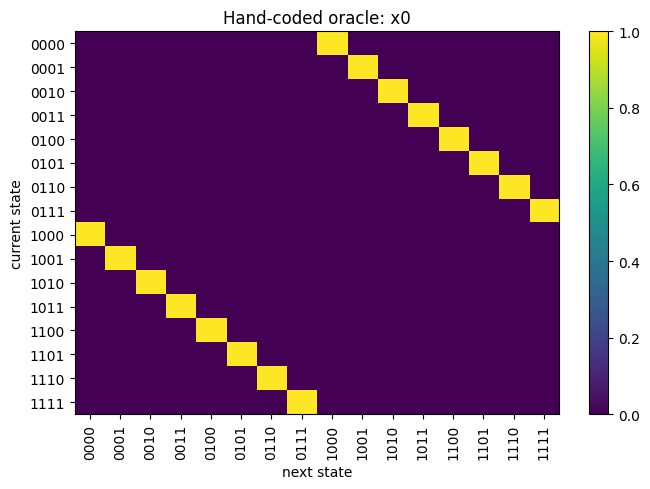

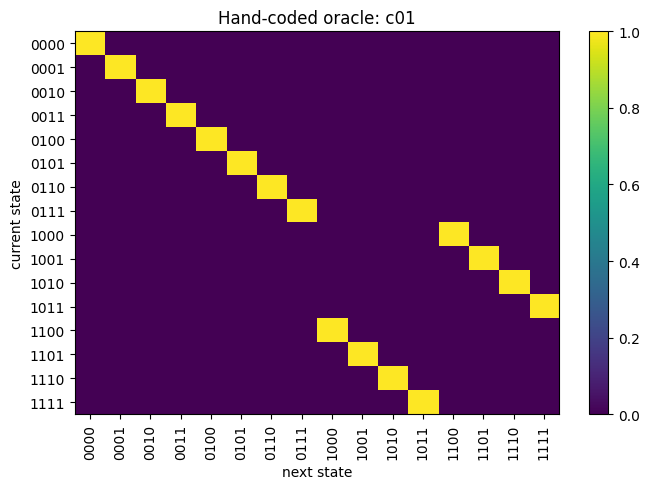

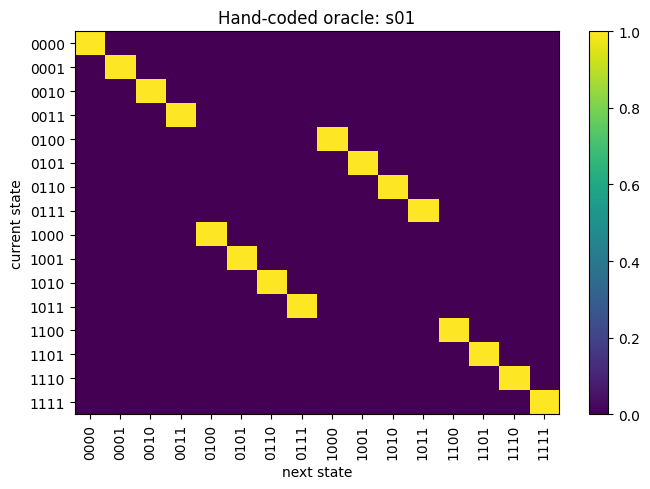

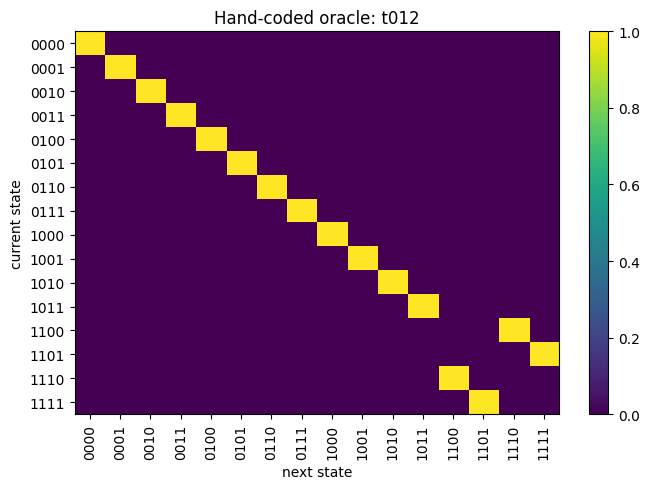

In [4]:

def plot_matrix(matrix, title):
    arr = matrix.detach().cpu().numpy()

    plt.figure(figsize=(7,5))
    plt.imshow(arr, aspect="auto")
    plt.xlabel("next state")
    plt.ylabel("current state" if arr.shape[0] == 16 else "(gate, current-state) pair")
    plt.xticks(range(16), [f"{i:04b}" for i in range(16)], rotation=90)

    if arr.shape[0] == 16:
        plt.yticks(range(16), [f"{i:04b}" for i in range(16)])
    else:
        plt.yticks([])

    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

for gate in ["x0", "c01", "s01", "t012"]:
    plot_matrix(
        ORACLE[gate_to_id[gate]],
        f"Hand-coded oracle: {gate}",
    )



## 4. Trainable transition-matrix executor

We parameterize each row by logits:

$$
P_g[s,:]
=
\operatorname{softmax}(A_g[s,:]).
$$

There are only

$$
52\times16\times16 = 13{,}312
$$

trainable scalars.

No attention, LayerNorm, MLP, residual stream, or embedding symmetry remains in this abstraction.

That is deliberate: this is the smallest object that captures **acquisition of the reusable Boolean operator**.


In [5]:

class TransitionMatrixExecutor(nn.Module):
    def __init__(self):
        super().__init__()

        self.logits = nn.Parameter(
            torch.zeros(len(GATES), 16, 16)
        )

        nn.init.normal_(
            self.logits,
            mean=0.0,
            std=1e-2,
        )

    def matrices(self):
        return self.logits.softmax(-1)

    def local(self, states, gates):
        # states: [B], gates: [B]
        return self.matrices()[gates, states]

    def compose(self, starts, gates):
        # starts: [B]
        # gates: [B,D]

        p = F.one_hot(
            starts,
            num_classes=16,
        ).float()

        matrices = self.matrices()

        for t in range(gates.shape[1]):
            current_matrix = matrices[gates[:,t]]

            p = torch.bmm(
                p[:,None,:],
                current_matrix,
            ).squeeze(1)

        return p



## 5. Data tensors

Outcome and process conditions use the exact same examples and minibatches.


In [6]:

train_rng = random.Random(DATA_SEED)
train_examples = [
    sample_example(train_rng)
    for _ in range(TRAIN_SIZE)
]

test_examples = [
    sample_example(random.Random(TEST_SEED+i))
    for i in range(TEST_SIZE)
]

def tensorize(examples):
    starts = torch.tensor(
        [x[0] for x in examples],
        dtype=torch.long,
    )

    gates = torch.tensor(
        [
            [gate_to_id[g] for g in x[1]]
            for x in examples
        ],
        dtype=torch.long,
    )

    states = torch.tensor(
        [x[2] for x in examples],
        dtype=torch.long,
    )

    return starts, gates, states

TRAIN_START, TRAIN_GATES, TRAIN_STATES = tensorize(train_examples)
TEST_START, TEST_GATES, TEST_STATES = tensorize(test_examples)

print(TRAIN_START.shape)
print(TRAIN_GATES.shape)
print(TRAIN_STATES.shape)


torch.Size([20000])
torch.Size([20000, 4])
torch.Size([20000, 4])



## 6. Same initialization, two losses

Outcome:

$$
\mathcal L_{\rm out}
=
-\log
\left[
e_{s_0}^{\top}
P_{g_1}P_{g_2}P_{g_3}P_{g_4}
\right]_{s_4}.
$$

Process:

$$
\mathcal L_{\rm proc}
=
-\frac14
\sum_{t=1}^{4}
\log
P_{g_t}[s_{t-1},s_t].
$$

For process training, each local target uses the gold preceding state. This is the exact analogue of teacher-forced trace supervision.


In [7]:

torch.manual_seed(MODEL_SEED)

base = TransitionMatrixExecutor().to(DEVICE)

outcome_model = copy.deepcopy(base)
process_model = copy.deepcopy(base)

assert torch.equal(
    outcome_model.logits,
    process_model.logits,
)

print("bit-identical initialization: True")

batch_rng = random.Random(BATCH_SEED)

BATCH_SCHEDULE = [
    [batch_rng.randrange(TRAIN_SIZE) for _ in range(BATCH_SIZE)]
    for _ in range(STEPS)
]


bit-identical initialization: True



## 7. Algorithm-recovery metrics

We compare learned matrices directly to the hand-coded oracle.

### Local argmax recovery

$$
A_\Phi
=
\frac1{52\cdot16}
\sum_{g,s}
\mathbf 1[
\arg\max_{s'}P_g[s,s']
=
\Phi_g(s)
].
$$

### Mean oracle probability

$$
Q_\Phi
=
\frac1{52\cdot16}
\sum_{g,s}
P_g[s,\Phi_g(s)].
$$

### Frobenius distance

$$
D_\Phi
=
\frac1{52}
\sum_g
\|P_g-P_g^\star\|_F^2.
$$


In [8]:

ORACLE_DEVICE = ORACLE.to(DEVICE)

@torch.no_grad()
def matrix_metrics(model):
    P = model.matrices()

    oracle_target = ORACLE_DEVICE.argmax(-1)

    local_accuracy = (
        P.argmax(-1) == oracle_target
    ).float().mean().item()

    oracle_probability = (
        P * ORACLE_DEVICE
    ).sum(-1).mean().item()

    frobenius = (
        (P - ORACLE_DEVICE).pow(2)
        .sum((-1,-2))
        .mean()
        .item()
    )

    return {
        "local_accuracy": local_accuracy,
        "oracle_probability": oracle_probability,
        "frobenius_distance": frobenius,
    }

print("hand-coded oracle:")
print({
    "local_accuracy": 1.0,
    "oracle_probability": 1.0,
    "frobenius_distance": 0.0,
})

print("\nshared initialization:")
print(matrix_metrics(base))


hand-coded oracle:
{'local_accuracy': 1.0, 'oracle_probability': 1.0, 'frobenius_distance': 0.0}

shared initialization:
{'local_accuracy': 0.057692307978868484, 'oracle_probability': 0.062490060925483704, 'frobenius_distance': 15.000411987304688}



## 8. Final-state and free local-rollout metrics


In [9]:

@torch.no_grad()
def final_accuracy(model):
    starts = TEST_START.to(DEVICE)
    gates = TEST_GATES.to(DEVICE)
    targets = TEST_STATES[:,-1].to(DEVICE)

    probs = model.compose(starts, gates)

    return (
        probs.argmax(-1) == targets
    ).float().mean().item()

@torch.no_grad()
def free_local_rollout_accuracy(model):
    current = TEST_START.to(DEVICE)
    gates = TEST_GATES.to(DEVICE)
    true_states = TEST_STATES.to(DEVICE)

    correct = 0
    total = 0

    for t in range(DEPTH):
        pred = model.local(
            current,
            gates[:,t],
        ).argmax(-1)

        correct += int(
            (pred == true_states[:,t]).sum()
        )
        total += len(pred)

        # free running: predicted state becomes next input
        current = pred

    return correct / total



## 9. Gradient at the near-uniform initialization

This is one of the most theorem-relevant diagnostics.

Define the oracle direction in logit space informally as

\[
\Delta^\star = P^\star-U,
\]

where

\[
U=\frac1{16}\mathbf1\mathbf1^\top.
\]

We compare:

- gradient norm;
- alignment of **negative gradient** with the oracle direction.

At an exactly uniform transition family, the population outcome objective has a strong symmetry: all reversible circuits map a uniform start distribution to a uniform final marginal. Process supervision breaks this symmetry locally because it conditions on the actual \((s,g)\) pair.


In [10]:

def gradient_diagnostic(model, mode, n=10_000):
    m = copy.deepcopy(model)

    starts = TRAIN_START[:n].to(DEVICE)
    gates = TRAIN_GATES[:n].to(DEVICE)
    states = TRAIN_STATES[:n].to(DEVICE)

    if mode == "outcome":
        p = m.compose(starts, gates)

        loss = F.nll_loss(
            (p + 1e-12).log(),
            states[:,-1],
        )

    else:
        losses = []
        previous = starts

        for t in range(DEPTH):
            p = m.local(
                previous,
                gates[:,t],
            )

            losses.append(
                F.nll_loss(
                    (p + 1e-12).log(),
                    states[:,t],
                )
            )

            previous = states[:,t]

        loss = torch.stack(losses).mean()

    m.zero_grad(set_to_none=True)
    loss.backward()

    grad = m.logits.grad.detach()

    uniform = torch.full_like(
        ORACLE_DEVICE,
        1/16,
    )

    oracle_direction = (
        ORACLE_DEVICE - uniform
    )

    neg_grad = -grad

    alignment = F.cosine_similarity(
        neg_grad.reshape(1,-1),
        oracle_direction.reshape(1,-1),
    ).item()

    return {
        "loss": float(loss.detach()),
        "gradient_norm": float(grad.norm()),
        "negative_gradient_oracle_alignment": alignment,
    }

grad_table = pd.DataFrame([
    {
        "supervision":"outcome",
        **gradient_diagnostic(base, "outcome"),
    },
    {
        "supervision":"process",
        **gradient_diagnostic(base, "process"),
    },
])

display(grad_table)


,supervision,loss,gradient_norm,negative_gradient_oracle_alignment
0,outcome,2.772660,0.002629,0.000047
1,process,2.772971,0.041164,0.815494



## 10. Matched training


In [11]:

def evaluate(model, step, mode):
    return {
        "step": step,
        "mode": mode,
        **matrix_metrics(model),
        "final_accuracy": final_accuracy(model),
        "free_local_rollout": free_local_rollout_accuracy(model),
    }

def train(model, mode):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
    )

    records = [
        evaluate(model, 0, mode)
    ]

    for step in range(1, STEPS+1):
        idx = BATCH_SCHEDULE[step-1]

        starts = TRAIN_START[idx].to(DEVICE)
        gates = TRAIN_GATES[idx].to(DEVICE)
        states = TRAIN_STATES[idx].to(DEVICE)

        if mode == "outcome":
            p = model.compose(
                starts,
                gates,
            )

            loss = F.nll_loss(
                (p + 1e-12).log(),
                states[:,-1],
            )

        elif mode == "process":
            losses = []
            previous = starts

            for t in range(DEPTH):
                p = model.local(
                    previous,
                    gates[:,t],
                )

                losses.append(
                    F.nll_loss(
                        (p + 1e-12).log(),
                        states[:,t],
                    )
                )

                previous = states[:,t]

            loss = torch.stack(losses).mean()

        else:
            raise ValueError(mode)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step in CHECKPOINTS:
            row = evaluate(
                model,
                step,
                mode,
            )
            row["loss"] = float(loss.detach())
            records.append(row)

    return pd.DataFrame(records)

outcome_history = train(
    outcome_model,
    "outcome",
)

process_history = train(
    process_model,
    "process",
)

history = pd.concat(
    [outcome_history, process_history],
    ignore_index=True,
)

display(history)


,step,mode,local_accuracy,oracle_probability,frobenius_distance,final_accuracy,free_local_rollout,loss
0,0,outcome,0.057692,0.062490,15.000412,0.0590,0.062625,NaN
1,1,outcome,0.056490,0.062496,15.009254,0.0635,0.055500,2.772764
2,2,outcome,0.058894,0.062513,15.022856,0.0660,0.061625,2.769753
3,5,outcome,0.064904,0.062529,15.062737,0.0665,0.067000,2.804652
4,10,outcome,0.061298,0.062612,15.105923,0.0655,0.068750,2.796355
5,25,outcome,0.056490,0.062838,15.143927,0.0555,0.060000,2.763898
6,50,outcome,0.063702,0.062818,15.181936,0.0595,0.058375,2.774186
7,100,outcome,0.063702,0.061870,15.376430,0.0645,0.066875,2.808366
8,0,process,0.057692,0.062490,15.000412,0.0590,0.062625,NaN
9,1,process,0.858173,0.073361,14.654921,0.0600,0.792500,2.773109



## 11. Matrix-recovery curves

These are more theorem-relevant than generic task accuracy.


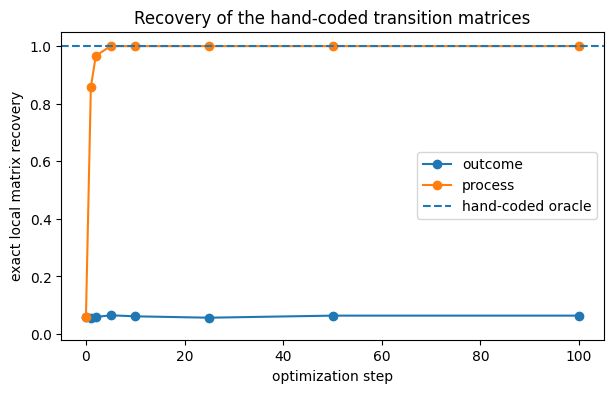

In [12]:

plt.figure(figsize=(7,4))

for mode, frame in history.groupby("mode"):
    plt.plot(
        frame["step"],
        frame["local_accuracy"],
        marker="o",
        label=mode,
    )

plt.axhline(
    1.0,
    linestyle="--",
    label="hand-coded oracle",
)

plt.xlabel("optimization step")
plt.ylabel("exact local matrix recovery")
plt.title("Recovery of the hand-coded transition matrices")
plt.ylim(-0.02, 1.05)
plt.legend()
plt.show()


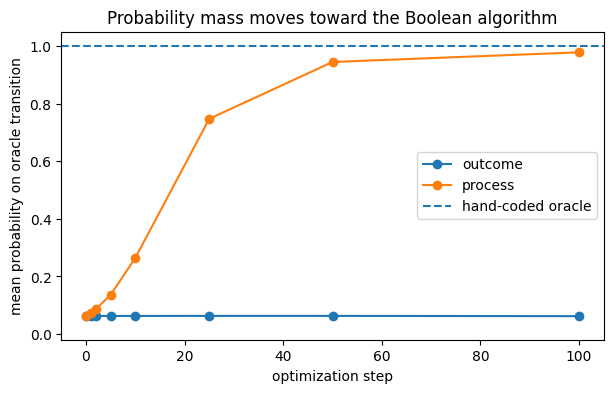

In [13]:

plt.figure(figsize=(7,4))

for mode, frame in history.groupby("mode"):
    plt.plot(
        frame["step"],
        frame["oracle_probability"],
        marker="o",
        label=mode,
    )

plt.axhline(
    1.0,
    linestyle="--",
    label="hand-coded oracle",
)

plt.xlabel("optimization step")
plt.ylabel("mean probability on oracle transition")
plt.title("Probability mass moves toward the Boolean algorithm")
plt.ylim(-0.02, 1.05)
plt.legend()
plt.show()


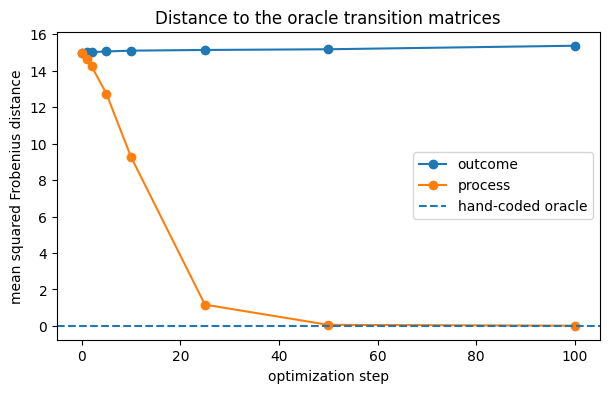

In [14]:

plt.figure(figsize=(7,4))

for mode, frame in history.groupby("mode"):
    plt.plot(
        frame["step"],
        frame["frobenius_distance"],
        marker="o",
        label=mode,
    )

plt.axhline(
    0.0,
    linestyle="--",
    label="hand-coded oracle",
)

plt.xlabel("optimization step")
plt.ylabel("mean squared Frobenius distance")
plt.title("Distance to the oracle transition matrices")
plt.legend()
plt.show()



## 12. Plot learned matrices directly

For each representative gate, compare:

1. exact hand-coded permutation matrix;
2. outcome-trained matrix;
3. process-trained matrix.

Raw Transformer \(W_Q/W_K\) matrices have basis/permutation symmetries, so these **effective transition matrices** are usually a cleaner mathematical object.


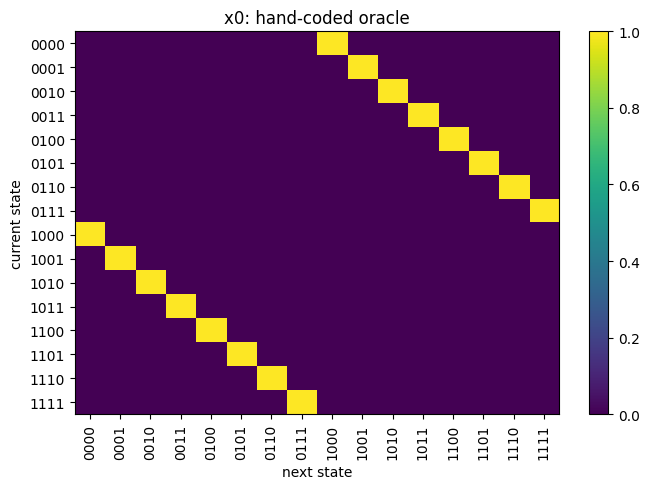

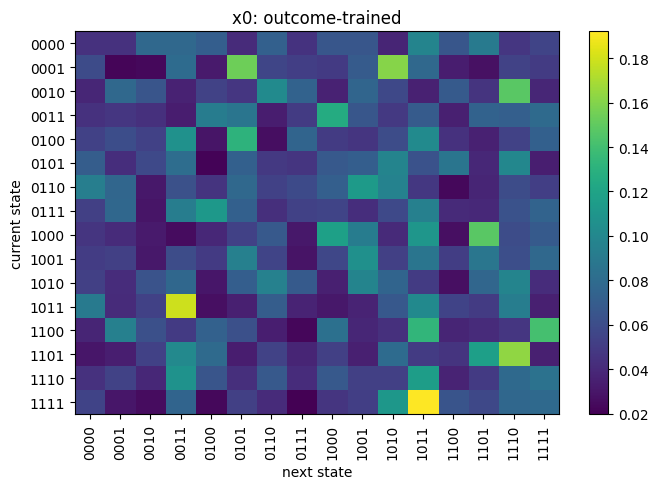

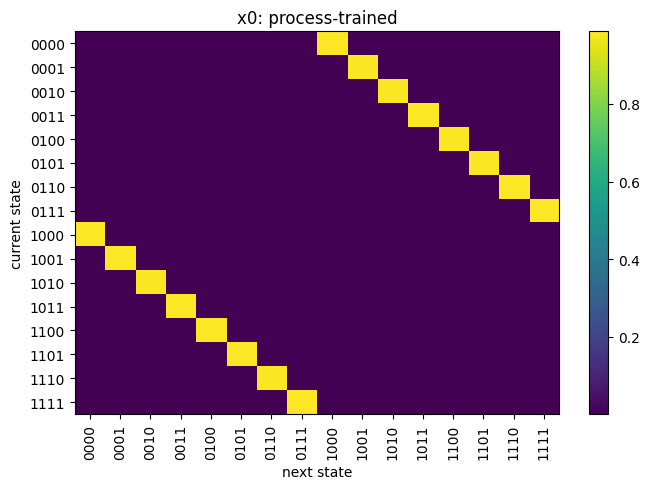

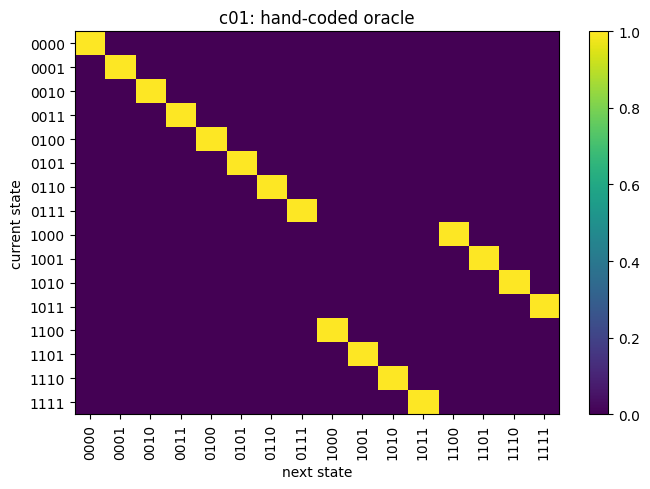

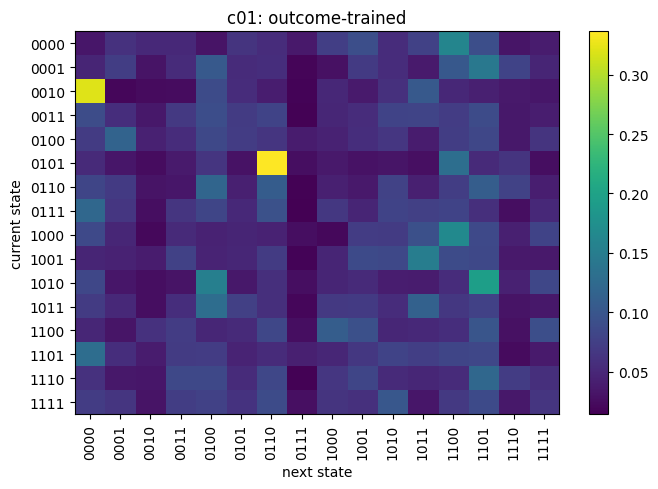

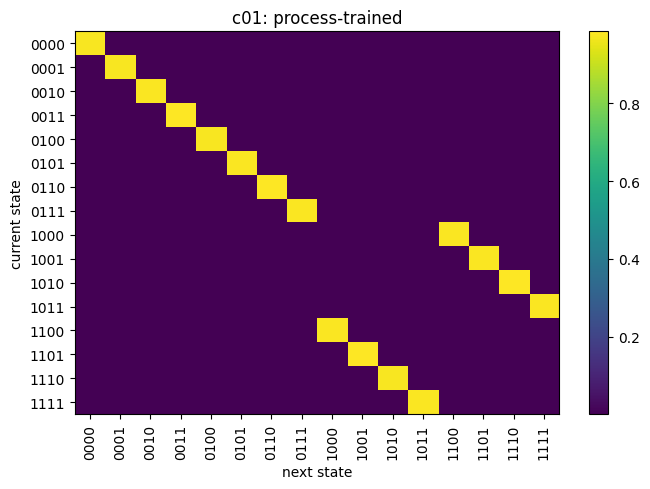

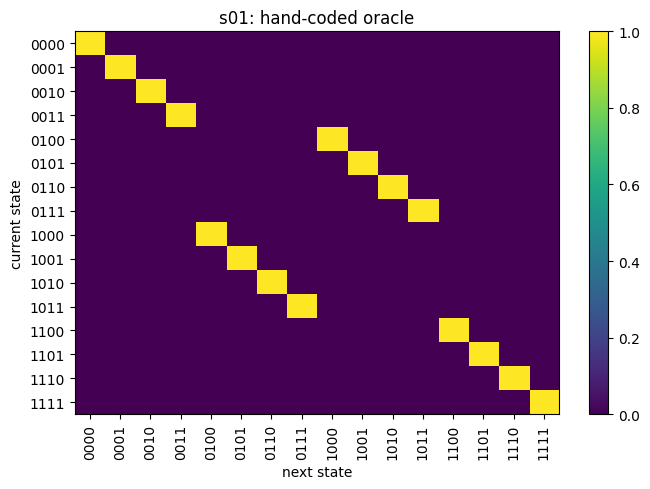

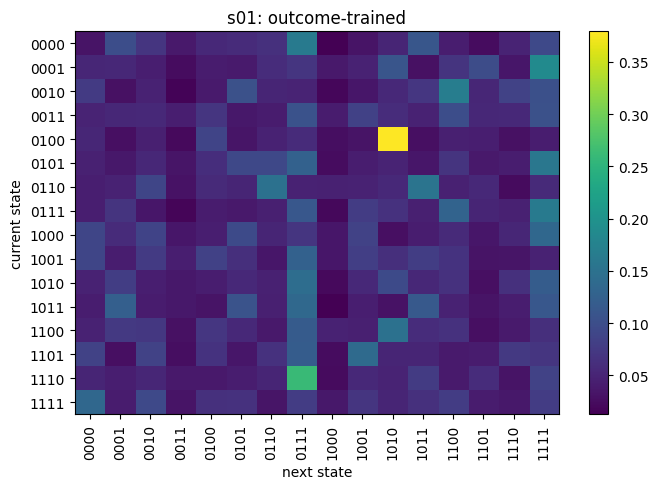

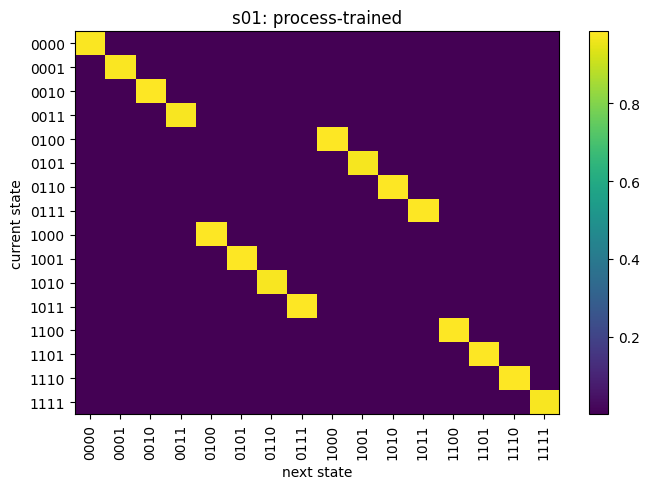

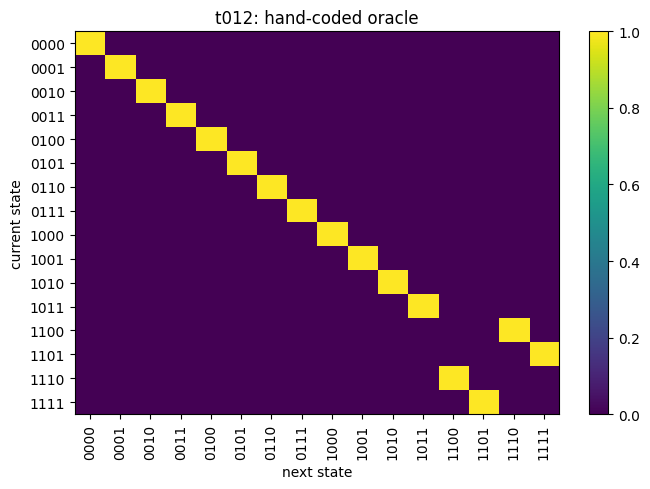

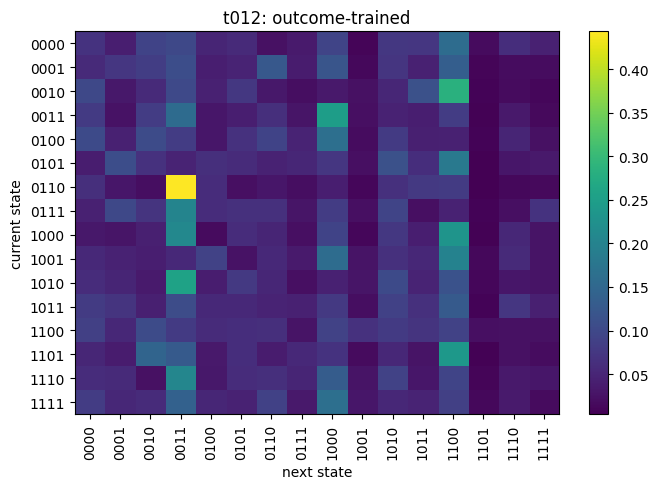

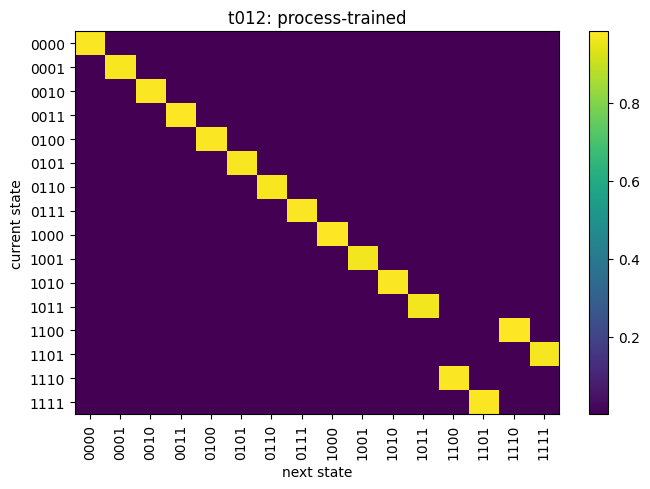

In [15]:

for gate in ["x0", "c01", "s01", "t012"]:
    gi = gate_to_id[gate]

    plot_matrix(
        ORACLE[gi],
        f"{gate}: hand-coded oracle",
    )

    plot_matrix(
        outcome_model.matrices()[gi],
        f"{gate}: outcome-trained",
    )

    plot_matrix(
        process_model.matrices()[gi],
        f"{gate}: process-trained",
    )



## 13. Full 832-by-16 operator matrix

Flatten all gate/state rows:

\[
M[(g,s),s'] = P_g[s,s'].
\]

This gives one image of the complete learned executor.


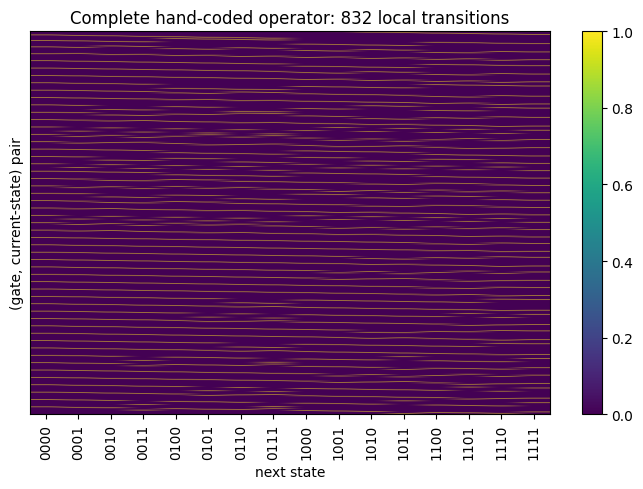

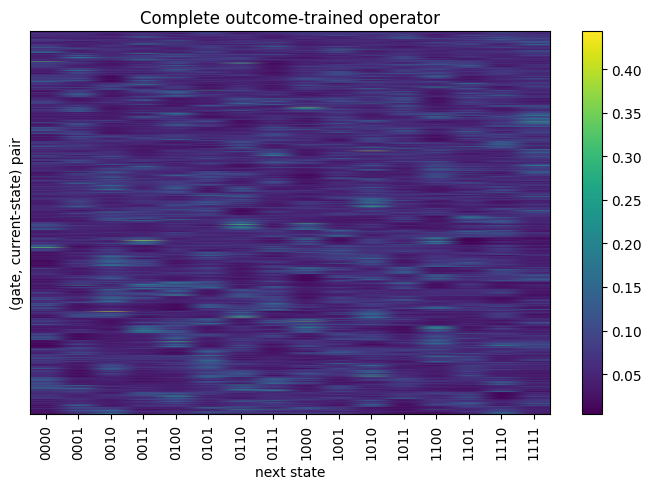

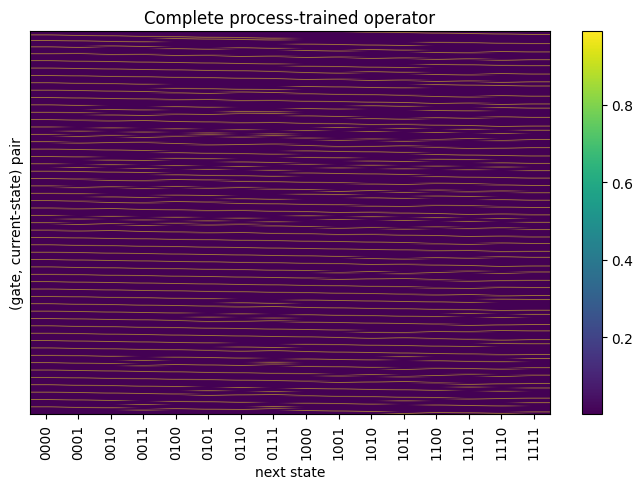

In [16]:

def flatten_operator(P):
    return P.reshape(-1,16)

plot_matrix(
    flatten_operator(ORACLE),
    "Complete hand-coded operator: 832 local transitions",
)

plot_matrix(
    flatten_operator(outcome_model.matrices()),
    "Complete outcome-trained operator",
)

plot_matrix(
    flatten_operator(process_model.matrices()),
    "Complete process-trained operator",
)



## 14. Final comparison


In [17]:

final = pd.DataFrame([
    {
        "model":"Hand-coded oracle",
        "local_accuracy":1.0,
        "oracle_probability":1.0,
        "frobenius_distance":0.0,
        "final_accuracy":1.0,
        "free_local_rollout":1.0,
    },
    {
        "model":"Outcome-trained",
        **matrix_metrics(outcome_model),
        "final_accuracy":final_accuracy(outcome_model),
        "free_local_rollout":free_local_rollout_accuracy(outcome_model),
    },
    {
        "model":"Process-trained",
        **matrix_metrics(process_model),
        "final_accuracy":final_accuracy(process_model),
        "free_local_rollout":free_local_rollout_accuracy(process_model),
    },
])

display(final)


,model,local_accuracy,oracle_probability,frobenius_distance,final_accuracy,free_local_rollout
0,Hand-coded oracle,1.000000,1.000000,0.000000,1.0000,1.000000
1,Outcome-trained,0.063702,0.061870,15.376430,0.0645,0.066875
2,Process-trained,1.000000,0.978462,0.008406,1.0000,1.000000



# Why this abstraction is useful for theorems

This model removes nearly every nuisance symmetry of a Transformer while retaining the core supervision question.

The exact algorithm is known:

$$
P_g^\star
$$

is a permutation matrix.

Both supervision schemes optimize exactly the same matrices.

The outcome condition is **not capacity-limited**: if it reached

$$
P_g=P_g^\star
$$

for every gate, then its four-matrix composition would solve the task exactly.

The interesting difference is therefore optimization/supervision geometry.

A particularly promising theorem point is the uniform family

$$
U=\frac1{16}\mathbf1\mathbf1^\top.
$$

Because every true gate is a permutation and the initial Boolean state is uniform, the terminal state marginal is also uniform. The outcome objective can therefore have a population-symmetric stationary/weak-gradient region around \(P_g=U\).

By contrast, the process objective conditions on the local state and gate:

$$
(s,g)\mapsto\Phi_g(s),
$$

so at \(U\) the local cross-entropy gradient points directly away from uniformity toward the corresponding oracle row.

This suggests an exact theorem program:

### Proposition A — oracle representation

For every reversible gate $g$, $P_g^\star$ is a permutation matrix and exact depth-\(D\) execution is

$$
e_{s_0}^{\top}
P_{g_1}^\star\cdots P_{g_D}^\star
=
e_{s_D}.
$$

### Proposition B — process gradient

For one local example $(s,g,s^\star)$,

$$
\nabla_{a_{g,s}}
\ell_{\rm proc}
=
p_{g,s}-e_{s^\star}.
$$

At the uniform initialization this is explicitly

$$
\frac1{16}\mathbf1-e_{\Phi_g(s)},
$$

which points directly toward the correct permutation row.

### Proposition C — outcome symmetry

At the uniform family $P_g=U$, every composed prediction is uniform:

$$
e_s^\top U^D
=
\frac1{16}\mathbf1^\top.
$$

Under uniformly distributed start states and reversible gates, the terminal marginal is also uniform. This creates a population symmetry in the terminal objective that is absent from the local process objective.

### Bridge back to the Transformer

The earlier hand-coded one-layer Transformer implements the same mapping with attention routing plus a ReLU transition table.

So the research structure can be:

$$
\boxed{\text{matrix theorem}}
\rightarrow
\boxed{\text{hand-coded attention realization}}
\rightarrow
\boxed{\text{learned one-layer Transformer}}
\rightarrow
\boxed{\text{full GPT experiments}}.
$$

That is substantially easier to defend mathematically than beginning with arbitrary learned \(96\times96\) attention matrices.
